# Género y mercado laboral en América Latina y el Caribe (1990–2014)
## Inés Zurita - Trabajo Integrador Final

Este cuaderno responde a las consignas del trabajo integrador final del curso de Herramientas básicas para el Análisis de Datos del Centro de e-Learning UTN BA.


# **1. Búsqueda y selección del Data Set**

# Pregunta principal
## ¿Cómo evolucionó la inserción laboral femenina en América Latina y el Caribe entre 1990 y 2014, y qué tan desigual fue ese avance entre países?

# Subpreguntas / KPIs:

#### KPI1 – Brecha de participación: ratio de participación laboral mujer/hombre. ¿Se cerró? ¿Dónde más y dónde menos?
#### KPI2 – Calidad del empleo: % de mujeres en empleo vulnerable vs. asalariadas. ¿El aumento de participación vino con mejores empleos?
#### KPI3 – Techo de cristal (2010): ¿la mayor participación laboral se tradujo en mujeres en cargos de decisión en empresas? (cruce participación laboral × % de firmas con gerenta mujer)

#Dataset

World Bank Gender Statistics — panel oficial del Banco Mundial con indicadores desagregados por sexo. Descargado desde Kaggle: https://www.kaggle.com/datasets/theworldbank/world-gender-statistics Fuente original: https://databank.worldbank.org/source/gender-statistics

La elección de este data set se fundamenta en que es la fuente estadística de referencia internacional en género, con metodología armonizada entre países (estimaciones modeladas OIT). Cubre 263 países/agregados, 688 indicadores y 57 años en un solo archivo.
Incluye indicadores directamente vinculados a "género en empresas" a nivel mundial: % de empresas con gerenta mujer, % de empresas con participación femenina en la propiedad, % de mujeres en puestos directivos, tasa de participación laboral femenina, ratio de participación laboral mujer/hombre, entre otros. Aquí nos interesa filtrar solo los 20 países de América Latina y el Caribe.

⚠️ Nota de alcance. Esta versión del dataset llega hasta 2016, no hasta la actualidad. Corresponde al snapshot 2017 del Banco Mundial publicado en Kaggle.

# **2. Ingesta y limpieza del Data Set**
El archivo viene en formato ancho. Cada fila es un par (país, indicador) y hay una columna por año (1960–2016). En primer lugar, debo transformarlo a formato largo para poder analizarlo posteriormente.

In [29]:
import pandas as pd
import numpy as np
import os
df = pd.read_csv('/content/Data.csv')
display(df.head())

print(f'Filas: {df.shape[0]:,}  |  Columnas: {df.shape[1]}')
df.head(3)

,Country.Name,Country.Code,Indicator.Name,Indicator.Code,1960,1961,1962,1963,1964,1965,...,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
0,Arab World,ARB,"Access to anti-retroviral drugs, female (%)",SH.HIV.ARTC.FE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,3.585854,5.611509,7.350393,8.645366,10.059527,12.358258,15.225028,17.751386,21.102336,NaN
1,Arab World,ARB,"Access to anti-retroviral drugs, male (%)",SH.HIV.ARTC.MA.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,4.407830,6.393077,7.520210,9.119101,10.627401,11.652603,13.841550,15.956337,18.406402,NaN
2,Arab World,ARB,"Account at a financial institution, female (% ...",WP_time_01.3,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Arab World,ARB,"Account at a financial institution, male (% ag...",WP_time_01.2,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Arab World,ARB,"Adolescent fertility rate (births per 1,000 wo...",SP.ADO.TFRT,133.555013,134.159119,134.857912,134.504576,134.105211,133.569626,...,49.999851,49.887046,49.781207,49.672975,49.536047,49.383745,48.796558,48.196418,NaN,NaN


Filas: 180,944  |  Columnas: 61


,Country.Name,Country.Code,Indicator.Name,Indicator.Code,1960,1961,1962,1963,1964,1965,...,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
0,Arab World,ARB,"Access to anti-retroviral drugs, female (%)",SH.HIV.ARTC.FE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,3.585854,5.611509,7.350393,8.645366,10.059527,12.358258,15.225028,17.751386,21.102336,NaN
1,Arab World,ARB,"Access to anti-retroviral drugs, male (%)",SH.HIV.ARTC.MA.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,4.407830,6.393077,7.520210,9.119101,10.627401,11.652603,13.841550,15.956337,18.406402,NaN
2,Arab World,ARB,"Account at a financial institution, female (% ...",WP_time_01.3,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
# Dimensiones del dataset crudo
print('Países / agregados :', df['Country.Name'].nunique())
print('Indicadores        :', df['Indicator.Name'].nunique())
print('Columnas-año       :', sum(c.isdigit() for c in df.columns))
print()
print('Tipos de dato:')
print(df.dtypes.value_counts())

Países / agregados : 263
Indicadores        : 688
Columnas-año       : 57

Tipos de dato:
float64    57
object      4
Name: count, dtype: int64


## 2.1 Revisión inicial
Revisamos tipos, nulos, duplicados y estructura para limpieza de datos.

In [5]:
# Duplicados
print('Filas duplicadas completas      :', df.duplicated().sum())
print('Duplicados por (país, indicador):', df.duplicated(['Country.Name','Indicator.Code']).sum())

# Nulos globales en las columnas-año
yrs_all = [c for c in df.columns if c.isdigit()]
print(f'\nCeldas de datos: {df[yrs_all].size:,}')
print(f'Nulas          : {df[yrs_all].isna().sum().sum():,} ({df[yrs_all].isna().mean().mean()*100:.1f}%)')

# El dataset mezcla países con agregados regionales ---
agregados = ['World','Arab World','Latin America & Caribbean','European Union','OECD members']
print('\nAgregados presentes (hay que excluirlos):',
      [a for a in agregados if a in set(df['Country.Name'])])

Filas duplicadas completas      : 0
Duplicados por (país, indicador): 0

Celdas de datos: 10,313,808
Nulas          : 9,112,018 (88.3%)

Agregados presentes (hay que excluirlos): ['World', 'Arab World', 'Latin America & Caribbean', 'European Union', 'OECD members']


Hallazgos:

No hay duplicados (país, indicador)
El 88.3% de las celdas está vacía/Null — no todos los indicadores existen para todos los años.
El dataset mezcla países con agregados regionales (World, Latin America & Caribbean, etc.). Si no se filtran, se duplica información y se rompen los promedios.

## 2.2. Selección de datos dentro del DataSet
Filtrado: 22 países y 14 indicadores


Se seleccionan dentro del Data Set con datos a nivel mundial, solo los países pertenecientes a América Latina y el Caribe. Asimismo, se toman indicadores de género para responder a las preguntas realizadas.

In [6]:
PAISES_ES = {
    'Argentina':'Argentina', 'Bolivia':'Bolivia', 'Brazil':'Brasil', 'Chile':'Chile',
    'Colombia':'Colombia', 'Costa Rica':'Costa Rica', 'Cuba':'Cuba',
    'Dominican Republic':'República Dominicana', 'Ecuador':'Ecuador', 'El Salvador':'El Salvador',
    'Guatemala':'Guatemala', 'Haiti':'Haití', 'Honduras':'Honduras', 'Jamaica':'Jamaica',
    'Mexico':'México', 'Nicaragua':'Nicaragua', 'Panama':'Panamá', 'Paraguay':'Paraguay',
    'Peru':'Perú', 'Trinidad and Tobago':'Trinidad y Tobago', 'Uruguay':'Uruguay',
    'Venezuela, RB':'Venezuela'
}

SUBREGION = {
    **{k:'Cono Sur' for k in ['Argentina','Brasil','Chile','Paraguay','Uruguay']},
    **{k:'Región Andina' for k in ['Bolivia','Colombia','Ecuador','Perú','Venezuela']},
    **{k:'Centroamérica y México' for k in ['Costa Rica','El Salvador','Guatemala',
                                            'Honduras','Nicaragua','Panamá','México']},
    **{k:'Caribe' for k in ['Cuba','Haití','Jamaica','República Dominicana','Trinidad y Tobago']}
}

# código_BM : (nombre en español, dimensión analítica, unidad)
IND = {
    'SL.TLF.CACT.FE.ZS': ('Participación laboral femenina',   'Participación',        '% de mujeres 15+'),
    'SL.TLF.CACT.MA.ZS': ('Participación laboral masculina',  'Participación',        '% de varones 15+'),
    'SL.TLF.CACT.FM.ZS': ('Ratio participación mujer/varón',  'Participación',        '% (mujer/varón)'),
    'SL.EMP.VULN.FE.ZS': ('Empleo vulnerable femenino',       'Calidad del empleo',   '% del empleo femenino'),
    'SL.EMP.WORK.FE.ZS': ('Asalariadas',                      'Calidad del empleo',   '% del empleo femenino'),
    'SL.EMP.MPYR.FE.ZS': ('Empleadoras',                      'Calidad del empleo',   '% del empleo femenino'),
    'SL.UEM.TOTL.FE.ZS': ('Desempleo femenino',               'Calidad del empleo',   '% de la PEA femenina'),
    'SL.SRV.EMPL.FE.ZS': ('Empleo femenino en servicios',     'Estructura sectorial', '% del empleo femenino'),
    'SL.AGR.EMPL.FE.ZS': ('Empleo femenino en agricultura',   'Estructura sectorial', '% del empleo femenino'),
    'SG.GEN.LSOM.ZS':    ('Mujeres en puestos directivos',    'Liderazgo',            '% del total de directivos'),
    'SG.GEN.PARL.ZS':    ('Bancas parlamentarias femeninas',  'Liderazgo',            '% de bancas'),
    'IC.FRM.FEMM.ZS':    ('Firmas con gerenta mujer',         'Liderazgo empresarial','% de firmas'),
    'IC.FRM.FEMO.ZS':    ('Firmas con propiedad femenina',    'Liderazgo empresarial','% de firmas'),
    'NY.GDP.PCAP.CD':    ('PBI per cápita',                   'Contexto',             'USD corrientes'),
}

ANIO_INI, ANIO_FIN = 1990, 2014

print(f'{len(PAISES_ES)} países · {len(IND)} indicadores · ventana {ANIO_INI}–{ANIO_FIN}')

22 países · 14 indicadores · ventana 1990–2014


In [7]:
# Cobertura de cada indicador candidato ANTES de decidir (para justificar la selección)
tmp = df[df['Country.Name'].isin(PAISES_ES)]
yrs_win = [str(y) for y in range(ANIO_INI, ANIO_FIN+1)]
celdas = len(PAISES_ES) * len(yrs_win)

cob = []
for cod, (nom, dim, _) in IND.items():
    s = tmp[tmp['Indicator.Code'] == cod]
    cob.append({'indicador': nom, 'dimension': dim,
                'cobertura_%': round(s[yrs_win].notna().sum().sum() / celdas * 100, 1)})

cobertura = pd.DataFrame(cob).sort_values('cobertura_%', ascending=False)
cobertura

,indicador,dimension,cobertura_%
0,Participación laboral femenina,Participación,100.0
1,Participación laboral masculina,Participación,100.0
2,Ratio participación mujer/varón,Participación,100.0
13,PBI per cápita,Contexto,99.5
6,Desempleo femenino,Calidad del empleo,96.0
7,Empleo femenino en servicios,Estructura sectorial,78.2
8,Empleo femenino en agricultura,Estructura sectorial,77.8
4,Asalariadas,Calidad del empleo,76.5
10,Bancas parlamentarias femeninas,Liderazgo,72.7
5,Empleadoras,Calidad del empleo,66.0


La tabla justifica la decisión de diseño: los tres indicadores del eje temporal (participación femenina, masculina y su ratio) tienen 100% de cobertura, mientras que los de liderazgo empresarial rondan el 3–6%. Por eso el KPI 3 es una foto de 2010 y no una serie.

In [8]:
dfx = df[df['Country.Name'].isin(PAISES_ES) & df['Indicator.Code'].isin(IND)].copy()
print(f'Subset filtrado: {dfx.shape[0]} filas x {dfx.shape[1]} columnas')
print('Países sin datos:', set(PAISES_ES) - set(dfx['Country.Name']) or 'ninguno')

Subset filtrado: 308 filas x 61 columnas
Países sin datos: ninguno


## 2.3. Reestructuración: de formato ancho a formato largo

Con melt() pasamos a una fila por (país, indicador, año), que es el formato que necesitan tanto pandas como Power BI.

In [9]:
yrs = [str(y) for y in range(1960, 2017)]

lg = dfx.melt(
    id_vars=['Country.Name','Country.Code','Indicator.Code'],
    value_vars=yrs,
    var_name='anio',
    value_name='valor'
)
lg['anio'] = lg['anio'].astype('int16')

print(f'Formato largo: {lg.shape[0]:,} filas')
print(f'Nulos: {lg.valor.isna().sum():,} ({lg.valor.isna().mean()*100:.1f}%)')
lg.head(3)

Formato largo: 17,556 filas
Nulos: 11,287 (64.3%)


,Country.Name,Country.Code,Indicator.Code,anio,valor
0,Argentina,ARG,SL.EMP.MPYR.FE.ZS,1960,NaN
1,Argentina,ARG,SL.AGR.EMPL.FE.ZS,1960,NaN
2,Argentina,ARG,SL.SRV.EMPL.FE.ZS,1960,NaN


## 2.4. Tratamiento de nulos

Decisión: no se imputa. Se recorta a la ventana 1990–2014 (donde la cobertura es alta) y se eliminan las celdas sin dato.

Por qué no imputar: cada fila es una observación estadística oficial de un país en un año concreto.

En este dataset, una celda vacía no es un dato perdido: es un año en el que ese país directamente no relevó ese indicador. Chile y Haití, por ejemplo, no tienen ningún registro de empleo vulnerable femenino en toda la serie.

Rellenar esos huecos con la media o la mediana regional generaría valores que no existen en la fuente oficial y que luego se mostrarían en el dashboard como si fueran mediciones reales. Además, imputar con un promedio empuja a todos los países hacia el valor central, y este trabajo busca precisamente medir cuánto se diferencian entre sí: el relleno destruiría la variación que se quiere analizar.

Se evaluó la interpolación lineal como alternativa, pero solo aplicaría a 400 de las 2.343 celdas vacías (17%), ya que el resto no tiene observaciones a ambos lados entre las cuales estimar.

Criterio adoptado: trabajar con menos observaciones pero todas verificables, y documentar la cobertura de cada indicador (tabla de la sección 2) en lugar de ocultarla.

In [10]:
#Limpieza para trabajar solo con datos existentes y verificables

lg = lg[lg.anio.between(ANIO_INI, ANIO_FIN)]
n_antes = len(lg)
lg = lg.dropna(subset=['valor'])

print(f'Ventana {ANIO_INI}–{ANIO_FIN} y sin nulos: {len(lg):,} filas')
print(f'Celdas descartadas por falta de dato: {n_antes - len(lg):,}')

Ventana 1990–2014 y sin nulos: 5,357 filas
Celdas descartadas por falta de dato: 2,343


In [11]:
# Chequear duplicados en la selección de datos del dataset
dups = lg.duplicated(['Country.Code','Indicator.Code','anio']).sum()
print('Duplicados (país, indicador, año):', dups)
lg = lg.drop_duplicates(['Country.Code','Indicator.Code','anio'])

Duplicados (país, indicador, año): 0


## 2.5. Estandarización
Se normalizan nombres de países al español, se agregan subregión, dimensión analítica y unidad, y se redondea a 2 decimales. Estas columnas descriptivas son las que después alimentan los filtros del dashboard en Power BI.

In [12]:
lg['pais']      = lg['Country.Name'].map(PAISES_ES)
lg['iso3']      = lg['Country.Code']
lg['subregion'] = lg['pais'].map(SUBREGION)
lg['indicador'] = lg['Indicator.Code'].map(lambda c: IND[c][0])
lg['dimension'] = lg['Indicator.Code'].map(lambda c: IND[c][1])
lg['unidad']    = lg['Indicator.Code'].map(lambda c: IND[c][2])
lg['codigo_bm'] = lg['Indicator.Code']
lg['valor']     = lg['valor'].round(2)
lg['decada']    = (lg['anio'] // 10 * 10).astype(str) + 's'

lg[['pais','subregion','anio','indicador','valor']].head(3)

,pais,subregion,anio,indicador,valor
9240,Argentina,Cono Sur,1990,Empleadoras,2.8
9241,Argentina,Cono Sur,1990,Empleo femenino en agricultura,0.2
9242,Argentina,Cono Sur,1990,Empleo femenino en servicios,81.6


## 2.6 Validación de rangos
Control de coherencia: todo indicador expresado en porcentaje debe caer dentro de [0, 100].

In [13]:
es_pct = lg['unidad'].str.startswith('%')
fuera  = lg[es_pct & ((lg.valor < 0) | (lg.valor > 100))]

print(f'Porcentajes fuera del rango [0,100]: {len(fuera)}')

lg[es_pct].groupby('indicador', observed=True)['valor'].agg(['min','max','mean','count']).round(1)

Porcentajes fuera del rango [0,100]: 0


,min,max,mean,count
indicador,,,,
Asalariadas,19.0,94.0,61.9,421
Bancas parlamentarias femeninas,2.0,53.1,17.4,400
Desempleo femenino,1.6,36.2,10.0,528
Empleadoras,0.5,6.2,2.5,363
Empleo femenino en agricultura,0.1,49.6,7.7,428
Empleo femenino en servicios,37.8,90.7,76.8,430
Empleo vulnerable femenino,11.6,75.6,36.4,358
Firmas con gerenta mujer,4.5,32.3,19.1,20
Firmas con propiedad femenina,23.1,65.3,37.7,35


## 2.7. Outliers: se marcan, no se eliminan

Se detectan con el criterio IQR × 1,5 calculado por indicador (no sobre el dataset entero: comparar un porcentaje de desempleo con el PBI per cápita no tendría sentido).

Decisión: se agrega una columna booleana es_outlier en vez de filtrar las filas. Al inspeccionarlos se ve que son valores reales y explicables, no errores de carga: Haití con ~49% de empleo femenino agrícola, República Dominicana con desempleo femenino cercano al 36%, Cuba con casi 49% de bancas parlamentarias. Eliminarlos borraría justamente los casos más informativos de la heterogeneidad regional, que es el corazón de la pregunta de investigación.

In [14]:
def marcar_outliers(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (serie < q1 - 1.5*iqr) | (serie > q3 + 1.5*iqr)

lg['es_outlier'] = lg.groupby('indicador', observed=True)['valor'].transform(marcar_outliers)

print(f'Outliers marcados: {lg.es_outlier.sum()} de {len(lg):,} ({lg.es_outlier.mean()*100:.1f}%)')
print()
print('¿Quiénes son? (top países por indicador)')
(lg[lg.es_outlier]
   .groupby(['indicador','pais'], observed=True).size()
   .sort_values(ascending=False).head(8))

Outliers marcados: 124 de 5,357 (2.3%)

¿Quiénes son? (top países por indicador)


indicador                        pais                
Desempleo femenino               República Dominicana    12
Empleo femenino en agricultura   Bolivia                 10
                                 Ecuador                 10
PBI per cápita                   Trinidad y Tobago       10
Bancas parlamentarias femeninas  Cuba                     7
Empleo femenino en agricultura   Paraguay                 7
Empleo femenino en servicios     Bolivia                  6
PBI per cápita                   Brasil                   5
dtype: int64

## 2.8. Tipado final y exportación

Las columnas de texto se convierten a category donde deja explícito que son variables categóricas. Se exportan tres archivos:

1) gender_lac_largo.csv -	Tabla de EDA

2) gender_lac_ancho.csv -	Un indicador por columna — correlaciones

3) dim_paises.csv	- Tabla dimensión país/subregión

In [15]:
cols = ['pais','iso3','subregion','anio','decada','dimension',
        'indicador','codigo_bm','unidad','valor','es_outlier']
lg = lg[cols]

for c in ['pais','iso3','subregion','dimension','indicador','codigo_bm','unidad','decada']:
    lg[c] = lg[c].astype('category')

lg = lg.sort_values(['pais','indicador','anio']).reset_index(drop=True)

lg.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5357 entries, 0 to 5356
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   pais        5357 non-null   category
 1   iso3        5357 non-null   category
 2   subregion   5357 non-null   category
 3   anio        5357 non-null   int16   
 4   decada      5357 non-null   category
 5   dimension   5357 non-null   category
 6   indicador   5357 non-null   category
 7   codigo_bm   5357 non-null   category
 8   unidad      5357 non-null   category
 9   valor       5357 non-null   float64 
 10  es_outlier  5357 non-null   bool    
dtypes: bool(1), category(8), float64(1), int16(1)
memory usage: 108.5 KB


In [16]:
OUT = '../data/processed'
os.makedirs(OUT, exist_ok=True)

# 1) Tabla de hechos (formato largo)
lg.to_csv(f'{OUT}/gender_lac_largo.csv', index=False, encoding='utf-8-sig')

# 2) Formato ancho (un indicador por columna)
ancho = lg.pivot_table(index=['pais','iso3','subregion','anio'],
                       columns='indicador', values='valor', observed=True).reset_index()
ancho.columns.name = None
ancho.to_csv(f'{OUT}/gender_lac_ancho.csv', index=False, encoding='utf-8-sig')

# 3) Tabla dimensión de países
dim = lg[['pais','iso3','subregion']].drop_duplicates().sort_values('pais')
dim.to_csv(f'{OUT}/dim_paises.csv', index=False, encoding='utf-8-sig')

print(f'gender_lac_largo.csv  ->  {lg.shape[0]:,} filas x {lg.shape[1]} columnas')
print(f'gender_lac_ancho.csv  ->  {ancho.shape[0]:,} filas x {ancho.shape[1]} columnas')
print(f'dim_paises.csv        ->  {dim.shape[0]} filas')

gender_lac_largo.csv  ->  5,357 filas x 11 columnas
gender_lac_ancho.csv  ->  550 filas x 18 columnas
dim_paises.csv        ->  22 filas


# **3 . Exploración y visualización**

En esta tercera parte se toma como punto de partido el dataset limpio (gender_lac_largo.csv, 5.357 filas) y se construye cinco visualizaciones con Matplotlib y Seaborn para responder la pregunta principal y los tres KPIs.

Gráfico	KPI	Qué muestra:

G1 · Evolución del ratio	KPI 1	La brecha de participación se achicó en toda la región

G2 · Comparación 1990 vs 2014	KPI 1	…pero a velocidades muy distintas según el país

G3 · Participación vs. precariedad	KPI 2	Más empleo femenino no significó mejor empleo femenino.

G4 · Mapa de calor	KPI 2	La jerarquía del empleo precario casi no se movió.

G5 · Techo de cristal	KPI 3	Trabajar y dirigir son fenómenos desconectados.





In [17]:
#configuración
import pandas as pd, numpy as np, matplotlib as mpl
import matplotlib.pyplot as plt, seaborn as sns
from matplotlib.lines import Line2D

sns.set_theme(style='whitegrid', font_scale=1.0)
mpl.rcParams.update({'figure.dpi':130,'savefig.dpi':150,'savefig.bbox':'tight',
 'axes.titlesize':14,'axes.titleweight':'bold','axes.labelsize':11,
 'axes.edgecolor':'#666','grid.color':'#e8e8e8','font.family':'DejaVu Sans'})

AZUL, ROJO, GRIS, VERDE = '#1f4e79', '#c0392b', '#b0b0b0', '#27ae60'
PAL = {'Cono Sur':'#1f4e79','Región Andina':'#c0392b',
       'Centroamérica y México':'#e67e22','Caribe':'#16a085'}

lg = pd.read_csv('../data/processed/gender_lac_largo.csv', encoding='utf-8-sig')
w  = lg.pivot_table(index=['pais','subregion','anio'], columns='indicador', values='valor').reset_index()
R='Ratio participación mujer/varón'; PF='Participación laboral femenina'
V='Empleo vulnerable femenino'; F='Firmas con gerenta mujer'; AS='Asalariadas'
IMG='../img'

## 3.1. KPI 1 — ¿Se cerró la brecha de participación laboral?

El ratio de participación mujer/varón mide qué porcentaje representa la tasa de actividad femenina respecto de la masculina. Un valor de 100 significaría igualdad plena; 50 significa que por cada varón económicamente activo hay media mujer

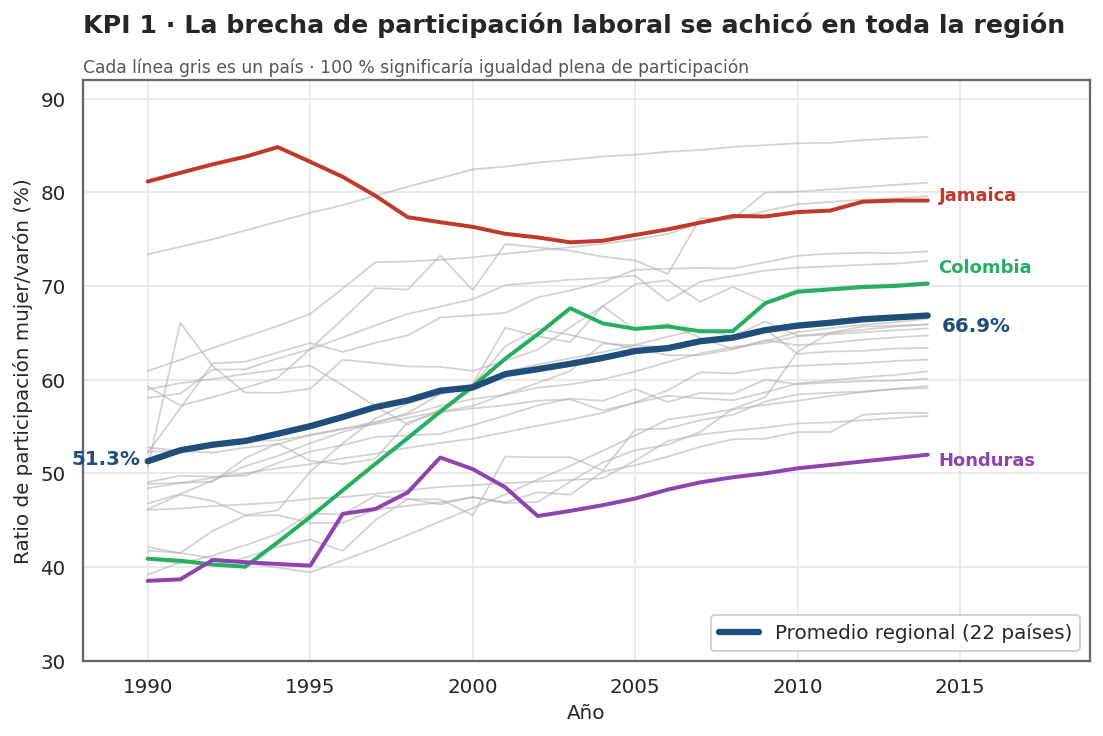

In [20]:
import os

fig, ax = plt.subplots(figsize=(10,5.8))
for p, g in w.groupby('pais'):
    g=g.sort_values('anio'); ax.plot(g.anio, g[R], color=GRIS, lw=1, alpha=.55, zorder=1)
reg = w.groupby('anio')[R].mean()
ax.plot(reg.index, reg.values, color=AZUL, lw=3.5, zorder=3, label='Promedio regional (22 países)')
for p,col,dy in [('Jamaica',ROJO,3),('Colombia',VERDE,9),('Honduras','#8e44ad',-3)]:
    g=w[w.pais==p].sort_values('anio')
    ax.plot(g.anio,g[R],color=col,lw=2.2,zorder=2)
    ax.annotate(p,(g.anio.iloc[-1],g[R].iloc[-1]),xytext=(6,dy),textcoords='offset points',
                color=col,fontweight='bold',fontsize=10,va='center')
ax.annotate(f'{reg.iloc[0]:.1f}%',(1990,reg.iloc[0]),xytext=(-42,-2),textcoords='offset points',
            color=AZUL,fontweight='bold',fontsize=11)
ax.annotate(f'{reg.iloc[-1]:.1f}%',(2014,reg.iloc[-1]),xytext=(8,-9),textcoords='offset points',
            color=AZUL,fontweight='bold',fontsize=11)
ax.set(xlim=(1988,2019), ylim=(30,92), xlabel='Año',
       ylabel='Ratio de participación mujer/varón (%)')
ax.set_title('KPI 1 · La brecha de participación laboral se achicó en toda la región',loc='left',pad=26)
ax.text(0,1.012,'Cada línea gris es un país · 100 % significaría igualdad plena de participación',
        transform=ax.transAxes,fontsize=9.5,color='#555')
ax.legend(loc='lower right',frameon=True,framealpha=.95)

# Ajuste para asegurar que la carpeta de imágenes sea escribible y esté en la estructura del proyecto
# 'OUT' es '../data/processed'. Queremos que IMG_OUTPUT_PATH sea '../data/img'.
IMG_OUTPUT_PATH = os.path.join(os.path.dirname(os.path.dirname(OUT)), 'data', 'img')
os.makedirs(IMG_OUTPUT_PATH, exist_ok=True)
plt.savefig(f'{IMG_OUTPUT_PATH}/g1_ratio_evolucion.png'); plt.show()

Interpretación:

Brecha decreciente: La línea azul oscura representa el promedio regional, y muestra una tendencia clara a la reducción de la brecha. Pasamos de un 51.3% en 1990 a un 66.9% en 2014, lo que indica un avance significativo en la incorporación de las mujeres al mercado laboral en relación con los hombres.

Heterogeneidad regional: Aunque el promedio regional mejora, las líneas grises (cada una un país) revelan una gran diversidad. Algunos países como Jamaica (línea roja) mantuvieron ratios altos a lo largo del período, mientras que otros como Honduras (línea morada) tuvieron ratios consistentemente más bajos.

Velocidades distintas: Países como Colombia (línea verde) muestran un crecimiento más pronunciado en su ratio de participación en ciertos períodos, indicando una aceleración en el cierre de la brecha en comparación con otros.

En resumen, el gráfico ilustra que, si bien la brecha de participación laboral se ha reducido en la región en promedio, la velocidad y el punto de partida de este cierre varían considerablemente entre los países.

Ningún país llegó a la paridad. Incluso el mejor caso de la región está a 14 puntos de un ratio de 100.

## 3.2. KPI 1 (continuación) — ¿El avance fue parejo?

El promedio esconde la heterogeneidad. Este gráfico compara el punto de partida (1990) y de llegada (2014) de cada país, ordenados por magnitud del cambio.

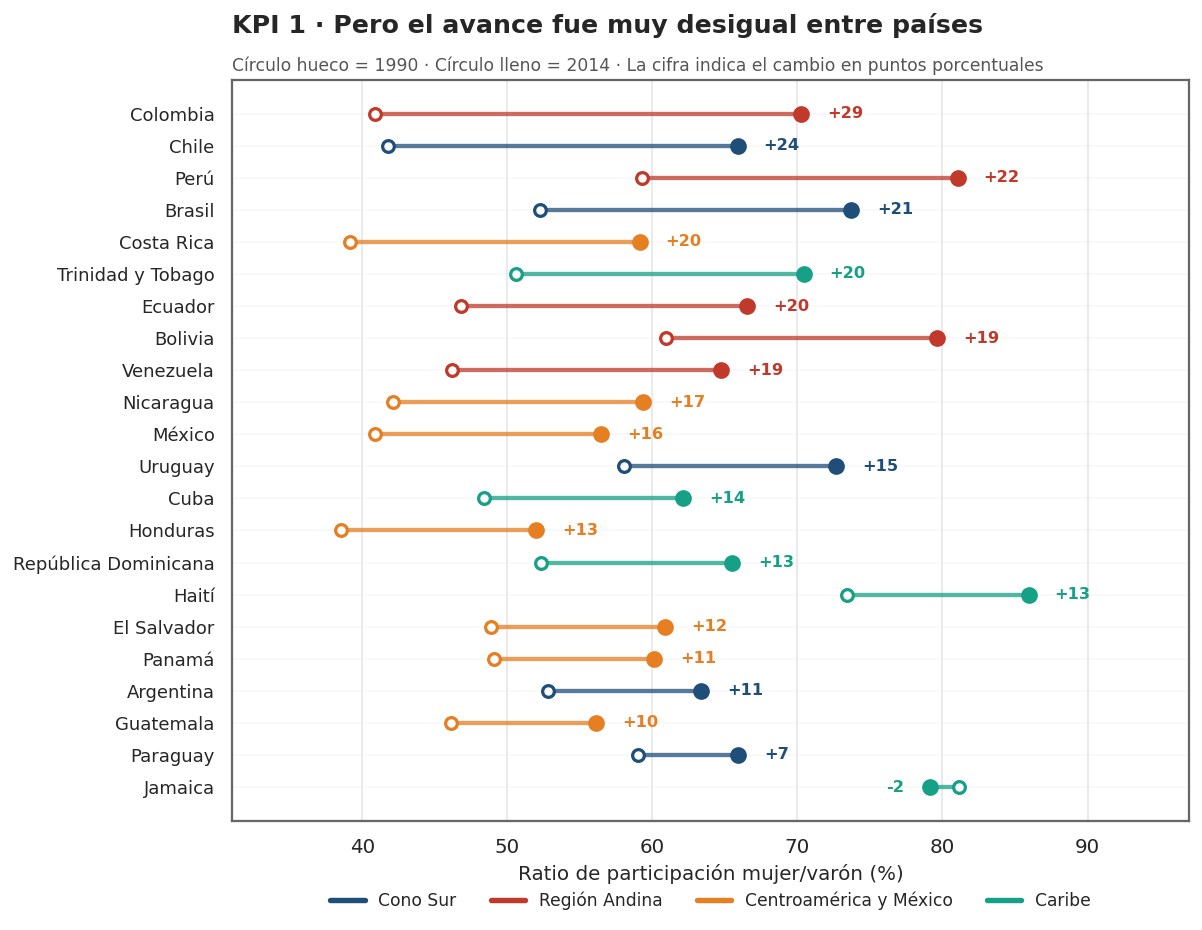

In [22]:
# G2: 1990 vs 2014
a=w[w.anio==1990].set_index('pais'); b=w[w.anio==2014].set_index('pais')
k=pd.DataFrame({'sub':a.subregion,'ini':a[R],'fin':b[R]})
k['d']=k.fin-k.ini; k=k.sort_values('d')
fig, ax = plt.subplots(figsize=(9.5,7.4))
y=np.arange(len(k))
for i,(p,r) in enumerate(k.iterrows()):
    c = PAL[r['sub']]
    ax.plot([r.ini,r.fin],[i,i],color=c,lw=2.4,alpha=.75,zorder=1,
            solid_capstyle='round')
    ax.scatter(r.ini,i,s=42,color='white',edgecolor=c,lw=1.8,zorder=2)
    ax.scatter(r.fin,i,s=68,color=c,zorder=3)
    off = 1.8 if r.d >= 0 else -1.8
    ax.text(r.fin+off,i,f'{r.d:+.0f}',va='center',ha='left' if r.d>=0 else 'right',
            fontsize=9,color=c,fontweight='bold')
ax.set_yticks(y); ax.set_yticklabels(k.index,fontsize=10)
ax.set(xlim=(31,97), xlabel='Ratio de participación mujer/varón (%)')
ax.set_title('KPI 1 · Pero el avance fue muy desigual entre países',loc='left',pad=26)
ax.text(0,1.012,'Círculo hueco = 1990 · Círculo lleno = 2014 · La cifra indica el cambio en puntos porcentuales',
        transform=ax.transAxes,fontsize=9.5,color='#555')
h=[Line2D([],[],color=c,lw=3,label=s) for s,c in PAL.items()]
ax.legend(handles=h,loc='upper center',bbox_to_anchor=(.5,-.075),ncol=4,
          frameon=False,fontsize=9.5)
ax.grid(axis='y',alpha=.25)

# Asegurar que el módulo os esté importado y definir la ruta de salida de imágenes
import os

# 'OUT' es '../data/processed'. Queremos que IMG_OUTPUT_PATH sea '../data/img'.
IMG_OUTPUT_PATH = os.path.join(os.path.dirname(os.path.dirname(OUT)), 'data', 'img')
os.makedirs(IMG_OUTPUT_PATH, exist_ok=True)
plt.savefig(f'{IMG_OUTPUT_PATH}/g2_slope_paises.png'); plt.show()

Interpretación del gráfico G2 · Comparación 1990 vs 2014:

Este gráfico, que continúa el análisis del KPI 1 (¿Se cerró la brecha de participación laboral?), muestra de forma muy clara la desigualdad en el avance entre países.

Eje Y (vertical): Cada fila representa un país de América Latina y el Caribe, ordenados de menor a mayor cambio en el ratio de participación de la mujer respecto al varón.

Eje X (horizontal): Muestra el Ratio de participación mujer/varón (%), donde un valor más alto indica una menor brecha (más cercanía a la paridad).

Círculo hueco: Indica el valor del ratio en 1990 (el punto de partida).

Círculo lleno: Indica el valor del ratio en 2014 (el punto de llegada).

Línea que une los círculos: Representa la trayectoria del cambio para cada país. Las líneas más largas o más inclinadas muestran un mayor avance.
Número con signo (+/-): Es el cambio en puntos porcentuales del ratio entre 1990 y 2014.

Colores: Indican la subregión a la que pertenece cada país (Cono Sur, Región Andina, Centroamérica y México, Caribe).


Gran disparidad en el avance: El avance osciló entre +29 y −2 puntos porcentuales: una diferencia de 31 puntos entre el país que más avanzó y el que menos.

Mientras países como Colombia (+29 puntos porcentuales), Chile (+24) y Perú (+22) mostraron avances muy significativos en la reducción de la brecha, otros como Jamaica (-2) incluso vieron un retroceso.

Colombia y Chile partían del fondo de la tabla (40,9% y 41,8%), lo que sugiere convergencia: hay más margen de mejora cuando se arranca bajo.
Paraguay (+7) y Jamaica (−2) cierran. En ambos casos la explicación es el punto de partida alto (59,0% y 81,2%), no un estancamiento genuino.

La posición relativa cambió poco. Haití encabezaba en 1990 y sigue encabezando en 2014; Honduras era el último y sigue último. El nivel subió para todos, pero el orden de la región se mantuvo.

No se observa un patrón claro por subregión: dentro del Cono Sur conviven Chile (+24) y Paraguay (+7). Esto indica que los factores determinantes son nacionales (mercado laboral, políticas de cuidado, estructura productiva) más que regionales.


Este gráfico refuerza la idea de que, a pesar de que el promedio regional muestra una mejora, la realidad país por país es muy variada, y el progreso en la igualdad de participación laboral femenina no fue uniforme en la región.


## 3.3. KPI 2 — Más mujeres trabajando, ¿pero en qué condiciones?

Que más mujeres entren al mercado laboral no dice nada sobre la calidad de esos empleos. El indicador de empleo vulnerable del Banco Mundial mide el porcentaje de trabajadoras por cuenta propia y familiares no remuneradas: ocupaciones sin contrato formal, sin aportes ni protección social.

Este gráfico cruza, para cada país, cuánto cambió la participación laboral femenina contra cuánto cambió la precariedad, entre el primer y el último año con dato disponible

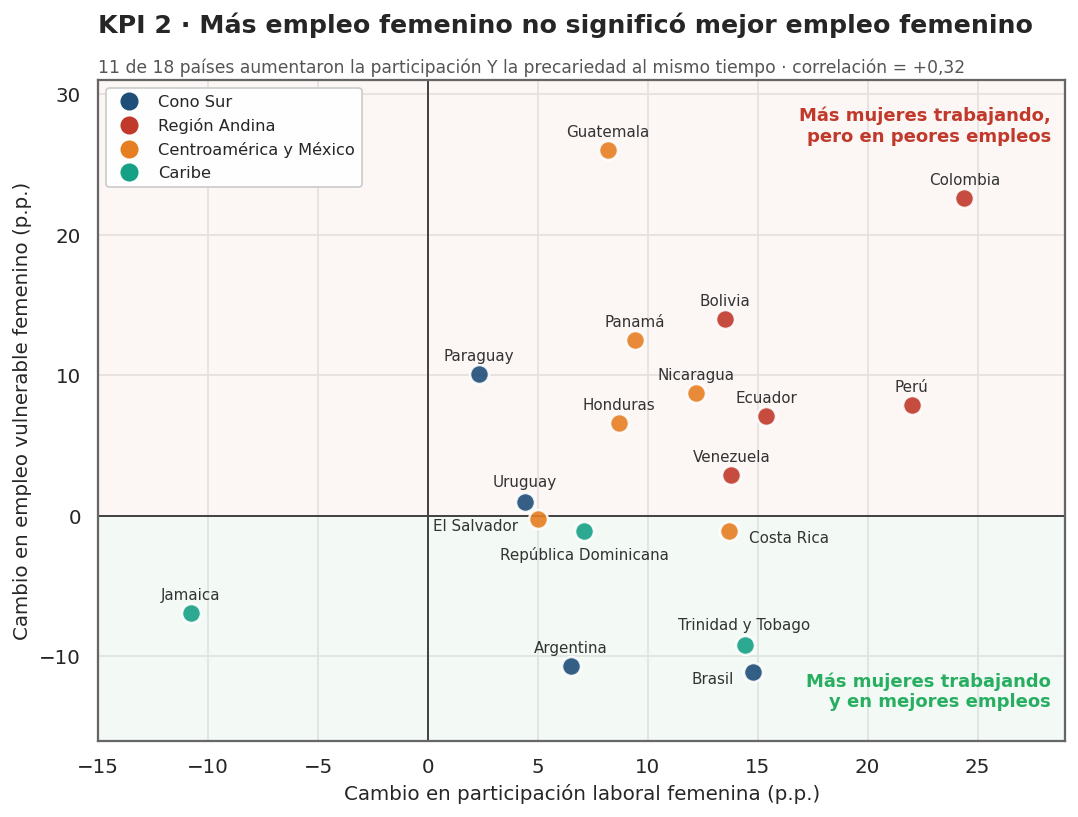

In [24]:
# G3: participación vs vulnerabilidad
v=lg[lg.indicador==V].dropna(subset=['valor']); rows=[]
for p,g in v.groupby('pais'):
    g=g.sort_values('anio'); y0,y1=g.anio.iloc[0],g.anio.iloc[-1]
    if y1-y0<10: continue
    pf=w[(w.pais==p)&(w.anio.isin([y0,y1]))].set_index('anio')[PF]
    rows.append({'pais':p,'sub':w[w.pais==p].subregion.iloc[0],
                 'dp':pf[y1]-pf[y0],'dv':g.valor.iloc[-1]-g.valor.iloc[0]})
kk=pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(9.6,6.6))
ax.axhline(0,color='#444',lw=1.1); ax.axvline(0,color='#444',lw=1.1)
ax.axhspan(0,32,color=ROJO,alpha=.045); ax.axhspan(-16,0,color=VERDE,alpha=.05)
OFF3={'Uruguay':(0,11,'center'),'El Salvador':(-11,-4,'right'),
      'República Dominicana':(0,-13,'center'),'Brasil':(-11,-4,'right'),
      'Trinidad y Tobago':(0,11,'center'),'Costa Rica':(11,-4,'left')}
for _,r in kk.iterrows():
    ax.scatter(r.dp,r.dv,s=110,color=PAL[r['sub']],alpha=.9,edgecolor='white',lw=1.4,zorder=3)
    dx,dy,ha = OFF3.get(r.pais,(0,10,'center'))
    ax.annotate(r.pais,(r.dp,r.dv),xytext=(dx,dy),textcoords='offset points',
                ha=ha,va='center',fontsize=8.4,color='#333')
ax.text(.985,.96,'Más mujeres trabajando,\npero en peores empleos',transform=ax.transAxes,
        ha='right',va='top',fontsize=10,color=ROJO,fontweight='bold')
ax.text(.985,.045,'Más mujeres trabajando\ny en mejores empleos',transform=ax.transAxes,
        ha='right',va='bottom',fontsize=10,color=VERDE,fontweight='bold')
ax.set(xlim=(-15,29), ylim=(-16,31),
       xlabel='Cambio en participación laboral femenina (p.p.)',
       ylabel='Cambio en empleo vulnerable femenino (p.p.)')
ax.set_title('KPI 2 · Más empleo femenino no significó mejor empleo femenino',loc='left',pad=26)
ax.text(0,1.012,'11 de 18 países aumentaron la participación Y la precariedad al mismo tiempo · correlación = +0,32',
        transform=ax.transAxes,fontsize=9.5,color='#555')
h=[Line2D([],[],marker='o',ls='',ms=9,color=c,label=s) for s,c in PAL.items()]
ax.legend(handles=h,loc='upper left',frameon=True,framealpha=.95,fontsize=9)

# Asegurar que el módulo os esté importado y definir la ruta de salida de imágenes
import os
IMG_OUTPUT_PATH = os.path.join(os.path.dirname(os.path.dirname(OUT)), 'data', 'img')
os.makedirs(IMG_OUTPUT_PATH, exist_ok=True)
plt.savefig(f'{IMG_OUTPUT_PATH}/g3_participacion_vs_vulnerabilidad.png'); plt.show()

Interpretación

En 11 de los 18 países con datos, la participación laboral femenina y el empleo vulnerable subieron al mismo tiempo. La correlación es positiva (+0,32): la incorporación de mujeres al mercado de trabajo tendió a producirse en los segmentos más precarios de la economía.

Eje X (horizontal): Mide el 'Cambio en participación laboral femenina (p.p.)', es decir, cuánto aumentó o disminuyó la participación de la mujer en el mercado laboral en puntos porcentuales entre el primer y último año con datos disponibles.

Eje Y (vertical): Mide el 'Cambio en empleo vulnerable femenino (p.p.)', indicando cuánto aumentó o disminuyó la proporción de mujeres en empleos vulnerables (sin contrato formal, aportes ni protección social) en puntos porcentuales en el mismo período.

Cuadrantes: El gráfico está dividido en cuatro cuadrantes por líneas en cero. El cuadrante superior derecho (en rojo claro) indica 'Más mujeres trabajando, pero en peores empleos' (aumenta participación y aumenta vulnerabilidad). El cuadrante inferior derecho (en verde claro) indica 'Más mujeres trabajando y en mejores empleos' (aumenta participación y disminuye vulnerabilidad).

Puntos de datos: Cada punto representa un país, con su color indicando la subregión. Algunos países tienen anotaciones para facilitar la identificación.

Observaciones clave del gráfico:

La mayoría en el cuadrante rojo: Una gran cantidad de países se encuentran en el cuadrante superior derecho, lo que significa que a la par de un aumento en la participación laboral femenina, también se observó un aumento en el empleo vulnerable femenino. Ejemplos claros son Guatemala, Colombia, Bolivia, Nicaragua y Ecuador.

Avances en la calidad: Solo algunos países, como Argentina, Brasil, El Salvador, República Dominicana, Trinidad y Tobago y Jamaica, lograron aumentar la participación femenina mientras reducían el empleo vulnerable (cuadrante verde). Destaca Jamaica con una reducción significativa en la participación vulnerable aunque con un ligero decrecimiento en la participación laboral femenina.

Correlación positiva: La nota en el título (correlación = +0,32) sugiere una correlación positiva débil entre el aumento de la participación laboral femenina y el aumento del empleo vulnerable, lo que indica que en la región, un mayor número de mujeres trabajando no siempre se tradujo en empleos de mejor calidad.

En conclusión, este gráfico revela que el progreso en la inclusión de las mujeres en el mercado laboral en América Latina y el Caribe a menudo se ha acompañado de un crecimiento en la precariedad de sus condiciones laborales, planteando un desafío importante en términos de calidad del empleo femenino.

## 3.4. KPI 2 (continuación) — ¿Cambió la jerarquía regional?

El mapa de calor muestra el nivel de empleo vulnerable femenino de cada país en cada año. Las celdas en blanco son años sin relevamiento: se dejan vacías deliberadamente, en coherencia con la decisión de no imputar tomada en el notebook 01.

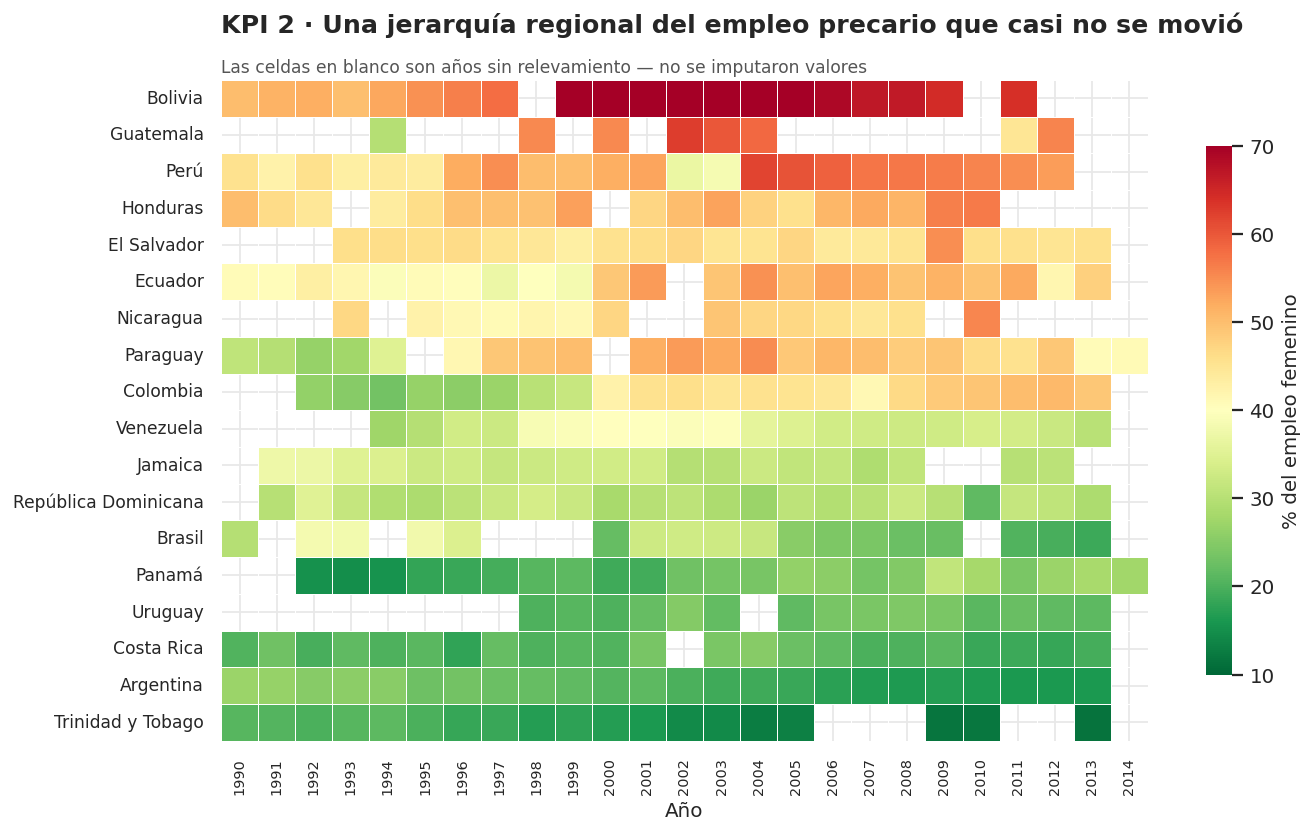

In [26]:
# G4: heatmap empleo vulnerable
hm=lg[lg.indicador==V].pivot_table(index='pais',columns='anio',values='valor')
orden=hm.mean(axis=1).sort_values(ascending=False).index
hm=hm.loc[orden]
fig, ax = plt.subplots(figsize=(11.5,6.6))
sns.heatmap(hm,cmap='RdYlGn_r',vmin=10,vmax=70,linewidths=.4,linecolor='white',
            cbar_kws={'label':'% del empleo femenino','shrink':.8}, ax=ax)
ax.set(xlabel='Año',ylabel='')
ax.set_title('KPI 2 · Una jerarquía regional del empleo precario que casi no se movió',loc='left',pad=26)
ax.text(0,1.012,'Las celdas en blanco son años sin relevamiento — no se imputaron valores',
        transform=ax.transAxes,fontsize=9.5,color='#555')
plt.setp(ax.get_xticklabels(),rotation=90,fontsize=8)
plt.setp(ax.get_yticklabels(),rotation=0,fontsize=9.5)
# Usar la ruta de salida de imágenes correcta
plt.savefig(f'{IMG_OUTPUT_PATH}/g4_heatmap_vulnerable.png'); plt.show()

Interpretación

Los países mantienen su posición relativa durante los 25 años. El gráfico se lee en bandas horizontales estables, no en un degradado que se mueva con el tiempo:

Bolivia, Guatemala, Perú y Honduras permanecen en la franja roja (50–70% del empleo femenino es vulnerable) durante prácticamente toda la serie.

Argentina, Costa Rica, Uruguay y Trinidad y Tobago se mantienen en verde (por debajo del 30%).

La diferencia entre extremos supera los 50 puntos porcentuales y no se achica.

Mientras el KPI 1 mostraba convergencia entre países en acceso al empleo, acá se ve lo contrario: en calidad del empleo la brecha entre países es estructural y persistente.

Las celdas blancas concentradas en Guatemala y Nicaragua también son informativas: son los países con sistemas estadísticos laborales menos regulares de la muestra.

##  3.5. KPI 3 — El techo de cristal

Última pregunta: ¿los países donde más mujeres trabajan son también los países donde más mujeres dirigen empresas?

Se cruza la participación laboral femenina de 2010 contra el porcentaje de firmas con una mujer en la gerencia general. Este indicador proviene de las Enterprise Surveys del Banco Mundial y solo está disponible como corte transversal, motivo por el cual no se analiza su evolución.

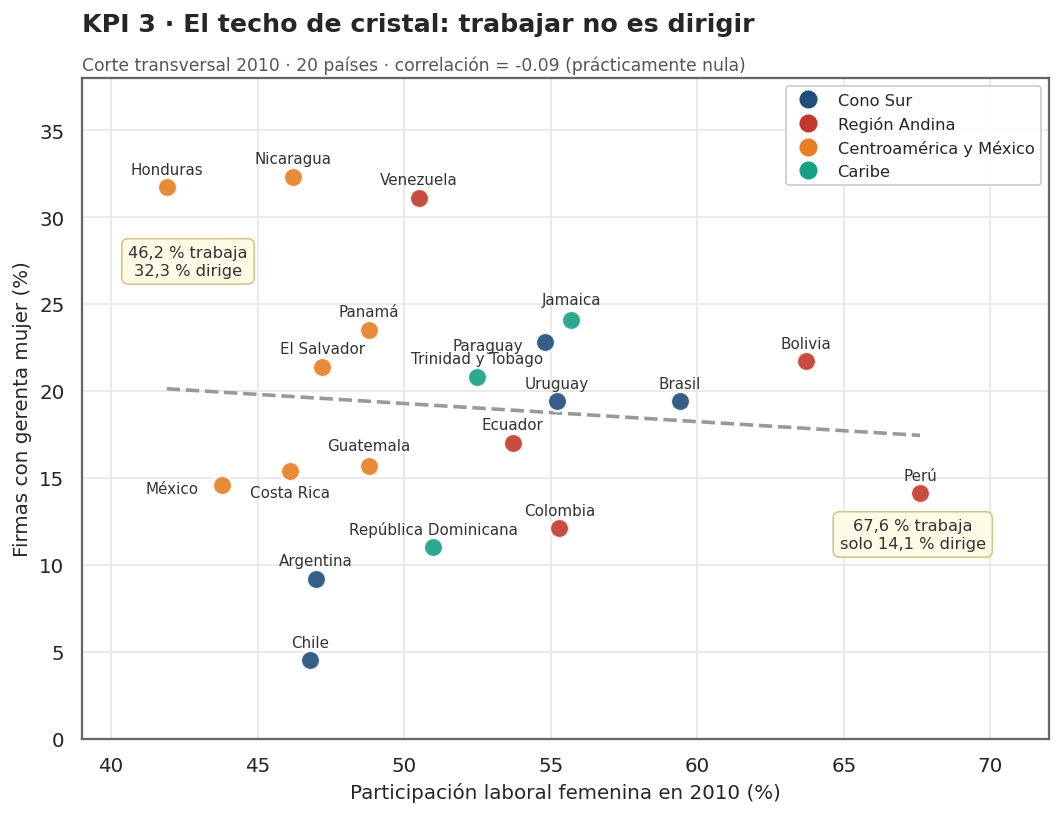

5 gráficos generados


In [28]:
f=lg[lg.indicador==F].dropna(subset=['valor'])[['pais','valor']].rename(columns={'valor':'firmas'})
p10=w[w.anio==2010][['pais','subregion',PF]].rename(columns={PF:'part'})
m=f.merge(p10,on='pais'); r=m.part.corr(m.firmas)
fig, ax = plt.subplots(figsize=(9.6,6.6))
sns.regplot(data=m,x='part',y='firmas',scatter=False,color='#999',
            line_kws={'lw':2,'ls':'--'},ci=None,ax=ax)
OFF5={'Costa Rica':(0,-12,'center'),'México':(-13,-2,'right'),'Guatemala':(0,11,'center'),
      'Jamaica':(0,11,'center'),'Paraguay':(-12,-2,'right')}
for _,q in m.iterrows():
    ax.scatter(q.part,q.firmas,s=115,color=PAL[q.subregion],alpha=.9,
               edgecolor='white',lw=1.4,zorder=3)
    dx,dy,ha = OFF5.get(q.pais,(0,10,'center'))
    ax.annotate(q.pais,(q.part,q.firmas),xytext=(dx,dy),textcoords='offset points',
                ha=ha,va='center',fontsize=8.4,color='#333')
for p,txt,dx,dy in [('Perú','67,6 % trabaja\nsolo 14,1 % dirige',-4,-30),
                    ('Nicaragua','46,2 % trabaja\n32,3 % dirige',-58,-54)]:
    q=m[m.pais==p].iloc[0]
    ax.annotate(txt,(q.part,q.firmas),xytext=(dx,dy),textcoords='offset points',
                fontsize=9,color='#333',ha='center',
                bbox=dict(boxstyle='round,pad=.4',fc='#fffbe6',ec='#d4c48a',lw=.9))
ax.set(xlim=(39,72), ylim=(0,38),
       xlabel='Participación laboral femenina en 2010 (%)',
       ylabel='Firmas con gerenta mujer (%)')
ax.set_title('KPI 3 · El techo de cristal: trabajar no es dirigir',loc='left',pad=26)
ax.text(0,1.012,f'Corte transversal 2010 · 20 países · correlación = {r:+.2f} (prácticamente nula)',
        transform=ax.transAxes,fontsize=9.5,color='#555')
h=[Line2D([],[],marker='o',ls='',ms=9,color=c,label=s) for s,c in PAL.items()]
ax.legend(handles=h,loc='upper right',frameon=True,framealpha=.95,fontsize=9)
plt.savefig(f'{IMG_OUTPUT_PATH}/g5_techo_de_cristal.png'); plt.show()

print('5 gráficos generados')

Interpretación

La correlación es −0,09: estadísticamente nula. La nube de puntos no tiene pendiente y la recta de ajuste es prácticamente horizontal.

Los contrastes son elocuentes:
Perú tiene la mayor participación laboral femenina de la región y uno de los porcentajes más bajos de empresas dirigidas por mujeres. Nicaragua, casi 21 puntos por debajo en participación, triplica a Perú en gerentas.

La conclusión es que acceder al mercado de trabajo y acceder a puestos de decisión son procesos gobernados por factores distintos.

La participación laboral responde a necesidad económica, estructura demográfica y oferta de empleo; el acceso a la gerencia responde a barreras culturales, redes profesionales y estructura empresarial. Aumentar el primero no mueve el segundo.

⚠️ Limitación. Con 20 observaciones de un único año, este resultado es indicativo y no permite inferencia causal. Se presenta como hallazgo exploratorio, no como conclusión estadística.

# **4  Síntesis de resultados**

Respuesta a la pregunta principal:
¿Cómo evolucionó la inserción laboral femenina en América Latina y el Caribe entre 1990 y 2014, y qué tan desigual fue ese avance entre países?

El avance fue real pero incompleto, y se dio en una sola de las tres dimensiones analizadas.

Acceso al mercado laboral	✅ Mejora clara y convergencia	Ratio M/H: 51,3% → 66,9%; desvío entre países 10,8 → 8,9

Calidad del empleo	⚠️ Sin mejora sistemática	11 de 18 países aumentaron participación y precariedad

Liderazgo empresarial	❌ Desconectado del resto	Correlación participación–gerentas: −0,09

Sobre la desigualdad entre países: el avance osciló entre +29 puntos (Colombia) y −2 (Jamaica). Los países convergieron en acceso, pero la jerarquía del empleo precario permaneció intacta: los mismos cuatro países encabezaban y cerraban la tabla en 1990 y en 2014.

Implicancia: medir el progreso de género únicamente con la tasa de participación laboral produce una imagen demasiado optimista. Los tres KPIs juntos muestran que más mujeres trabajando no equivale a mejores empleos ni a más mujeres decidiendo.

